In [1]:
import os
import json
import warnings
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import pyodbc  

import lightgbm as lgb
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
import optuna
import shap

from optuna import trial
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (classification_report, accuracy_score, precision_score, recall_score,
  f1_score, roc_auc_score,  average_precision_score,  confusion_matrix,  roc_curve, auc,
   ConfusionMatrixDisplay,PrecisionRecallDisplay, RocCurveDisplay)
from preprocessors import GroupMedianImputer, CategoricalCaster

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)


c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
conn = pyodbc.connect(
    "DRIVER={ODBC Driver 18 for SQL Server};"
    "SERVER=localhost;"  
    "DATABASE=NovaBank_CreditRisk;"
    "Trusted_Connection=yes;"
    "Encrypt=yes;"
    "TrustServerCertificate=yes;"
)

query = "SELECT * FROM dbo.vw_credit_risk_base"
df_raw = pd.read_sql(query, conn)

df_test = df_raw.copy()

In [3]:
#Target columns
target = "loan_status"

#numeric
numeric_cols = [
    "person_age",
    "person_income",
    "other_debt",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_term_months",
    "loan_percent_income",
    "debt_to_income_ratio",
    "loan_to_income_ratio",
    "credit_utilization_ratio",
    "cb_person_cred_hist_length",
    "open_accounts",
    "past_delinquencies"
]

categorical_cols = [
    "person_home_ownership",
    "loan_intent",
    "employment_type",
    "education_level",
    "cb_person_default_on_file"
]

In [4]:
X = df_test[numeric_cols + categorical_cols]
y = df_test[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set : {X_train.shape}")
print(f"Testing set : {X_test.shape}")

Training set : (26064, 19)
Testing set : (6517, 19)


In [5]:
#Cap outliers
X_train["person_age"] = X_train["person_age"].clip(upper=80)
X_test["person_age"]  = X_test["person_age"].clip(upper=80)

X_train["person_emp_length"] = X_train["person_emp_length"].clip(upper=60)
X_test["person_emp_length"]  = X_test["person_emp_length"].clip(upper=60)

X_train["debt_to_income_ratio"] = X_train["debt_to_income_ratio"].clip(upper=1.0)
X_test["debt_to_income_ratio"]  = X_test["debt_to_income_ratio"].clip(upper=1.0)

print(X_train[["person_age", "person_emp_length", "debt_to_income_ratio"]].max())


#Missing Flags
X_train["emp_length_missing"] = X_train["person_emp_length"].isna().astype(int)
X_test["emp_length_missing"]  = X_test["person_emp_length"].isna().astype(int)

X_train["loan_int_rate_missing"] = X_train["loan_int_rate"].isna().astype(int)
X_test["loan_int_rate_missing"]  = X_test["loan_int_rate"].isna().astype(int)

print(X_train[["emp_length_missing", "loan_int_rate_missing"]].sum())
print(X_test[["emp_length_missing", "loan_int_rate_missing"]].sum())


#has prior default
X_train["has_prior_default"] = (  X_train["cb_person_default_on_file"]
    .map({"Y": 1, "N": 0}))

X_test["has_prior_default"] = ( X_test["cb_person_default_on_file"]
    .map({"Y": 1, "N": 0}))


#high loan burden flag
X_train["high_loan_burden_flag"] = (
    (X_train["loan_to_income_ratio"] > 0.30) | (X_train["debt_to_income_ratio"] > 0.40) ).astype(int)

X_test["high_loan_burden_flag"] = (
    (X_test["loan_to_income_ratio"] > 0.30) | (X_test["debt_to_income_ratio"] > 0.40) ).astype(int)


#Log1p
log1p_features = [
    "person_income",
    "other_debt",
]
for col in log1p_features:
      X_train[f"{col}_log"] = np.log1p(X_train[col])
      X_test[f"{col}_log"]  = np.log1p(X_test[col])


person_age              80.0
person_emp_length       60.0
debt_to_income_ratio     1.0
dtype: float64
emp_length_missing        738
loan_int_rate_missing    2501
dtype: int64
emp_length_missing       157
loan_int_rate_missing    615
dtype: int64


In [6]:
numeric_LR = [
    "person_age",
    "person_income_log",
    "other_debt_log",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_term_months",
    "debt_to_income_ratio",
    "loan_to_income_ratio",
    "credit_utilization_ratio",
    "cb_person_cred_hist_length",
    "open_accounts",
    "past_delinquencies"
]

binary_LR = [
    "has_prior_default",
    "emp_length_missing",
    "loan_int_rate_missing",
    "high_loan_burden_flag"
]

categorical_LR = [
    "person_home_ownership",
    "loan_intent",
    "employment_type",
    "education_level"
]

In [7]:
num_preprocessing_LR = Pipeline([
    ("scaler", RobustScaler())
])

cat_preprocessing_LR = Pipeline([
    ("onehot", OneHotEncoder( handle_unknown="ignore",drop="first" ) )
])

# Ghép các nhóm biến
preprocessing_LR = ColumnTransformer([
    ("numeric", num_preprocessing_LR,numeric_LR ),
    ("binary","passthrough", binary_LR ),
    ("categorical",cat_preprocessing_LR,categorical_LR )
])


Classification Report- TRAIN SET
              precision    recall  f1-score   support

           0       0.93      0.77      0.84     20378
           1       0.49      0.78      0.60      5686

    accuracy                           0.77     26064
   macro avg       0.71      0.78      0.72     26064
weighted avg       0.83      0.77      0.79     26064

ROC-AUC: 0.8580
PR-AUC: 0.6819
Classification Report- TEST SET
              precision    recall  f1-score   support

           0       0.93      0.77      0.84      5095
           1       0.49      0.79      0.60      1422

    accuracy                           0.77      6517
   macro avg       0.71      0.78      0.72      6517
weighted avg       0.83      0.77      0.79      6517

ROC-AUC: 0.8607
PR-AUC: 0.6931


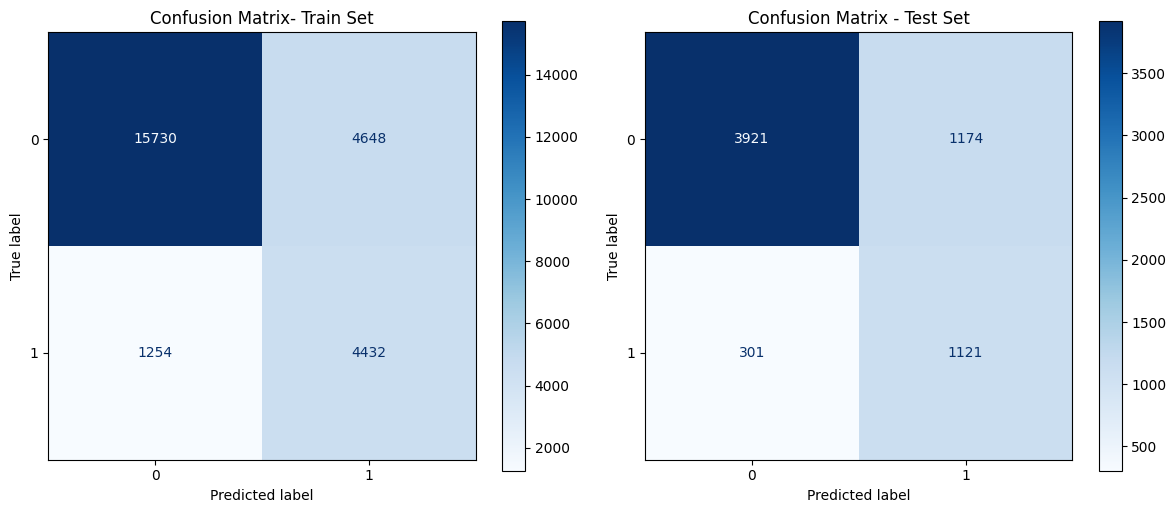

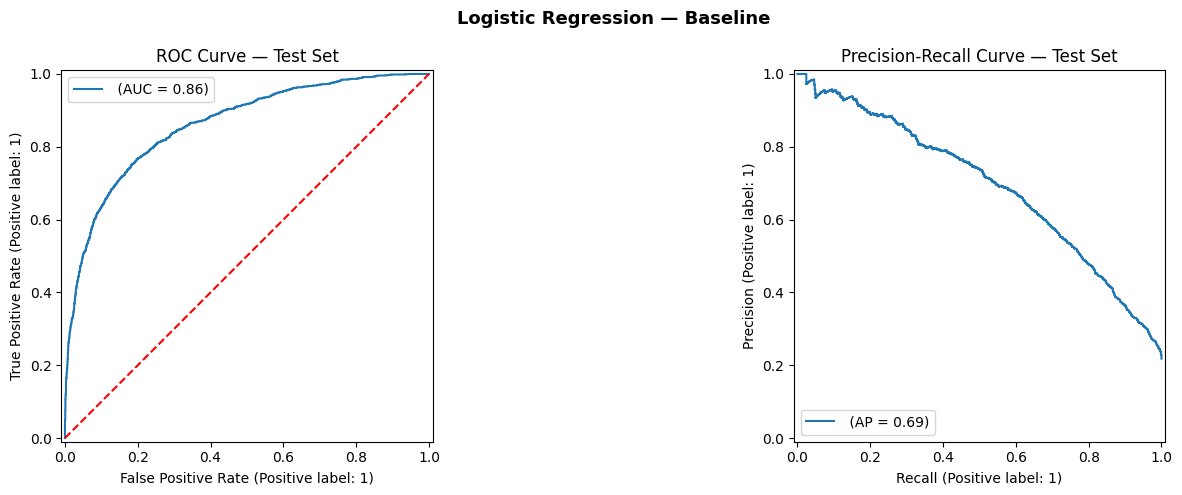

In [8]:
LR_pipeline = Pipeline([
        ("group_imputer", GroupMedianImputer()),
        ("preprocessing", preprocessing_LR),
        ("model", LogisticRegression(
            max_iter=1000,  # số lần lặp tối đa 
            random_state=42,  # random state để tái lập kết quả
            class_weight="balanced",   # cân bằng trọng số lớp
            solver="saga",   # thuật toán tối ưu phù hợp với regularization
            l1_ratio=0.0,  # L2 regularization
            C=1.0  # regularization strength 
        ))
    ])
lr_model = LR_pipeline.fit(X_train, y_train)

# set ngưỡng dự đoán
threshold = 0.5

# dự đoán xác suất và nhãn
y_train_proba_lr = LR_pipeline.predict_proba(X_train)[:, 1]
y_test_proba_lr = LR_pipeline.predict_proba(X_test)[:, 1]

# dự đoán nhãn dựa trên ngưỡng
y_train_pred_lr = (y_train_proba_lr >= threshold).astype(int)
y_test_pred_lr = (y_test_proba_lr >= threshold).astype(int)

# classification report
print("Classification Report- TRAIN SET")
print(classification_report(y_train, y_train_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_train, y_train_proba_lr):.4f}")
print(f"PR-AUC: {average_precision_score(y_train, y_train_proba_lr):.4f}")

print("Classification Report- TEST SET")
print(classification_report(y_test, y_test_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, y_test_proba_lr):.4f}")
print(f"PR-AUC: {average_precision_score(y_test, y_test_proba_lr):.4f}")


# Confusion Matrix — Train và Test
matrix_train = confusion_matrix(y_train, y_train_pred_lr, labels=[0, 1])
matrix_test = confusion_matrix(y_test, y_test_pred_lr, labels=[0, 1])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

display_train = ConfusionMatrixDisplay(
    confusion_matrix=matrix_train,
    display_labels=[0, 1]
)

display_train.plot(
    ax=axes[0],
    values_format="d",
    colorbar=True,
    cmap="Blues"
)

axes[0].set_title("Confusion Matrix- Train Set")

display_test = ConfusionMatrixDisplay(
    confusion_matrix=matrix_test,
    display_labels=[0, 1]
)

display_test.plot(
    ax=axes[1],
    values_format="d",
    colorbar=True,
    cmap="Blues"
)
axes[1].set_title("Confusion Matrix - Test Set")

plt.tight_layout()
plt.show()


#  ROC Curve Predictions on Test set
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Logistic Regression — Baseline", fontsize=13, fontweight="bold")

RocCurveDisplay.from_predictions(
    y_test, y_test_proba_lr,
    name="",
    ax=axes[0]
)
axes[0].plot([0, 1], [0, 1], color="red", linestyle="--", )
axes[0].legend()
axes[0].set_title("ROC Curve — Test Set")

PrecisionRecallDisplay.from_predictions(
    y_test, y_test_proba_lr,
    name="",
    ax=axes[1]
)
axes[1].set_title("Precision-Recall Curve — Test Set")

plt.tight_layout()
plt.show()

In [9]:
#set feature
numeric_LGBM = [
    "person_age",
    "person_income_log",
    "other_debt_log",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_term_months",
    "loan_percent_income",
    "debt_to_income_ratio",
    "loan_to_income_ratio",
    "credit_utilization_ratio",
    "cb_person_cred_hist_length",
    "open_accounts",
    "has_prior_default",
    "past_delinquencies",
    "emp_length_missing",
    "loan_int_rate_missing",
    "high_loan_burden_flag"
]

categorical_LGBM = [
    "person_home_ownership",
    "loan_intent",
    "employment_type",
    "education_level"
]

In [10]:
X_train_LGBM = X_train[numeric_LGBM + categorical_LGBM].copy()
X_test_LGBM = X_test[numeric_LGBM + categorical_LGBM].copy()

# Scale pos weight
n_negative = (y_train == 0).sum()
n_positive = (y_train == 1).sum()
scale_pos_weight = n_negative / n_positive
print("Scale_pos_weight:", round(scale_pos_weight, 4))

Scale_pos_weight: 3.5839


Classification Report — TRAIN SET
              precision    recall  f1-score   support

           0       0.96      0.95      0.96     20378
           1       0.83      0.85      0.84      5686

    accuracy                           0.93     26064
   macro avg       0.90      0.90      0.90     26064
weighted avg       0.93      0.93      0.93     26064

ROC-AUC: 0.9735
PR-AUC: 0.9356

Classification Report — TEST SET
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      5095
           1       0.79      0.78      0.78      1422

    accuracy                           0.91      6517
   macro avg       0.86      0.86      0.86      6517
weighted avg       0.91      0.91      0.91      6517

ROC-AUC: 0.9382
PR-AUC: 0.8850


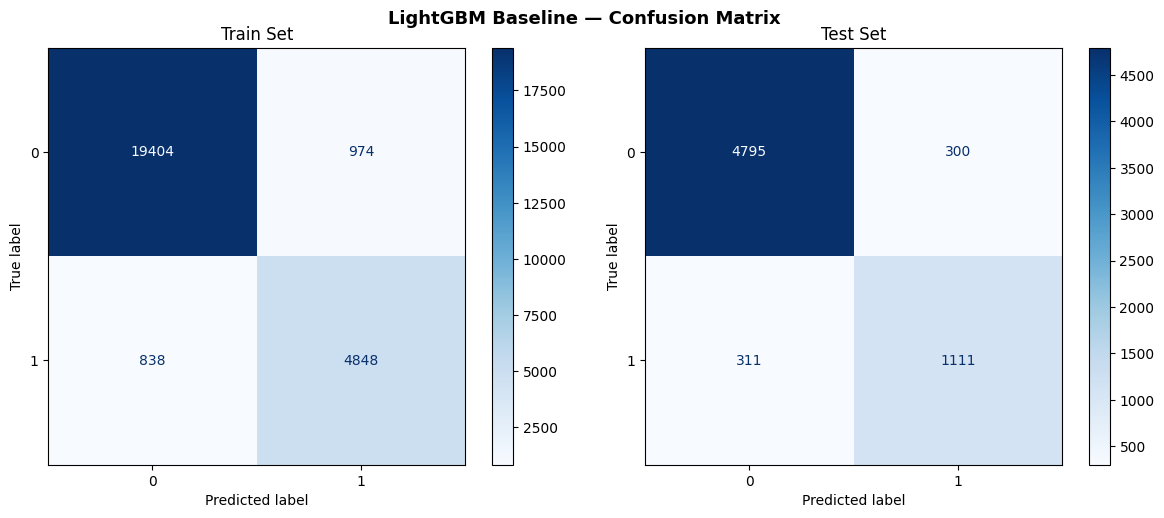

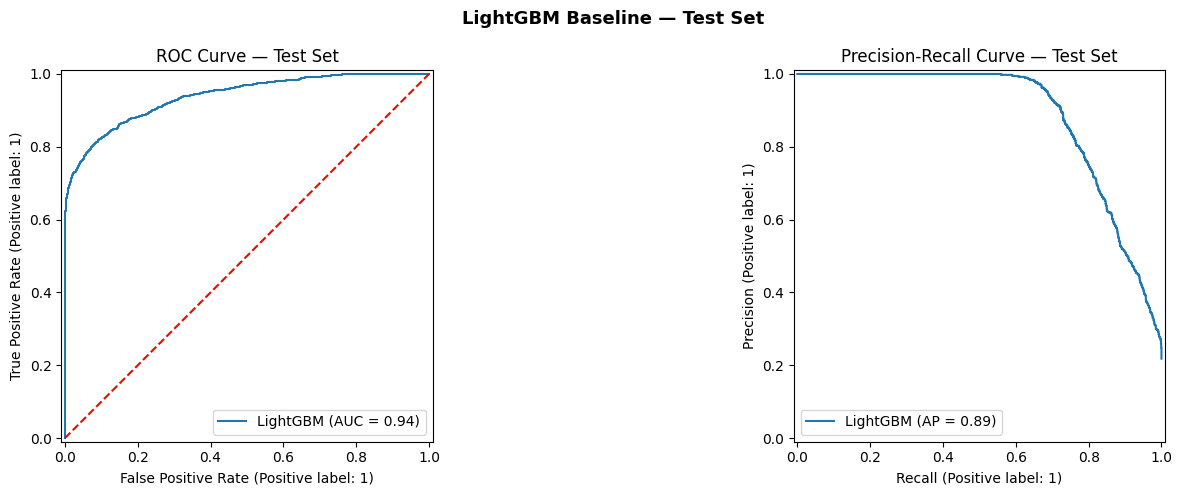

In [11]:
LGBM_pipeline = Pipeline([
    ("group_imputer", GroupMedianImputer()),
    ("caster", CategoricalCaster(cols=categorical_LGBM)),
    ("model", LGBMClassifier(   
        objective = "binary",                     #bài toán phân loại nhị phân
        boosting_type = "gbdt",                   #tt thuật boosting decision tree
        n_estimators = 100,                       #số lượng cây trong mô hình
        scale_pos_weight = scale_pos_weight ,     #trọng số phạt cho lớp dương
        random_state = 42,                        #random state để tái lập kết quả
        n_jobs = -1,                              #số lượng CPU sử dụng
        verbose = -1,                             #tắt log 
    ))
])

lgbm_model = LGBM_pipeline.fit(X_train_LGBM, y_train)

# set  ngưỡng dự đoán
threshold = 0.5

# dự đoán xác suất về lớp 1
y_train_proba_lgbm = lgbm_model.predict_proba(X_train_LGBM)[:, 1]
y_test_proba_lgbm = lgbm_model.predict_proba(X_test_LGBM)[:, 1]

# dự đoán nhãn dựa trên ngưỡng
y_train_pred_lgbm = (y_train_proba_lgbm >= threshold).astype(int)
y_test_pred_lgbm = (y_test_proba_lgbm >= threshold).astype(int)

# Classification Report
print("Classification Report — TRAIN SET")
print(classification_report(y_train, y_train_pred_lgbm))
print(f"ROC-AUC: {roc_auc_score(y_train, y_train_proba_lgbm):.4f}")
print(f"PR-AUC: {average_precision_score(y_train, y_train_proba_lgbm):.4f}")

print("\nClassification Report — TEST SET")
print(classification_report(y_test, y_test_pred_lgbm))
print(f"ROC-AUC: {roc_auc_score(y_test, y_test_proba_lgbm):.4f}")
print(f"PR-AUC: {average_precision_score(y_test, y_test_proba_lgbm):.4f}")

# Confusion Matrix 
matrix_train = confusion_matrix(y_train, y_train_pred_lgbm, labels=[0, 1])
matrix_test = confusion_matrix(y_test,  y_test_pred_lgbm,  labels=[0, 1])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("LightGBM Baseline — Confusion Matrix", fontsize=13, fontweight="bold")

ConfusionMatrixDisplay(matrix_train, display_labels=["0", "1"]).plot(
    ax=axes[0], values_format="d", colorbar=True, cmap="Blues"
)
axes[0].set_title("Train Set")

ConfusionMatrixDisplay(matrix_test, display_labels=["0", "1"]).plot(
    ax=axes[1], values_format="d", colorbar=True, cmap="Blues"
)
axes[1].set_title("Test Set")

plt.tight_layout()
plt.show()

# ROC & PR Curves 
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("LightGBM Baseline — Test Set", fontsize=13, fontweight="bold")

RocCurveDisplay.from_predictions(
    y_test, y_test_proba_lgbm, name="LightGBM", ax=axes[0]
)
axes[0].plot([0, 1], [0, 1], color="red", linestyle="--", )
axes[0].set_title("ROC Curve — Test Set")
axes[0].legend()

PrecisionRecallDisplay.from_predictions(
    y_test, y_test_proba_lgbm, name="LightGBM", ax=axes[1]
)
axes[1].set_title("Precision-Recall Curve — Test Set")

plt.tight_layout()
plt.show()

In [ ]:
SEED = 42
N_FOLDS = 5                 #số lượng fold trong cross-validation
N_TRIALS = 50               #số lượng thử nghiệm tối ưu hóa 

# khởi tạo kfold
kf = StratifiedKFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=SEED
)

def objective(trial):
    params = {
        "objective": "binary",                  # nhị phân
        "boosting_type": "gbdt",                # decision tree
        "random_state": SEED,
        "n_jobs": -1,                           # sử dụng tất cả CPU
        "verbosity": -1,                        # tắt log
        "metric": "average_precision",          # tối ưu hóa theo PR-AUC
        "n_estimators": 1500,                    #số lượng cây 
        "scale_pos_weight": scale_pos_weight,   #trọng số phạt cho lớp dương

        # Tham số cần tối ưu
        "max_depth": trial.suggest_int("max_depth", 3, 6),                              #độ sâu tối đa của cây
        "num_leaves": trial.suggest_int("num_leaves", 5, 60),                           #số lá của cây quyết định
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.04, log=True),    #tốc độ học
        "min_child_samples": trial.suggest_int("min_child_samples", 120, 400),          #số mẫu tối thiểu trong một node lá
        "min_split_gain": trial.suggest_float("min_split_gain", 0.05, 1.0),             #gain tối thiểu để phân chia node
        "reg_alpha": trial.suggest_float("reg_alpha", 0.001, 10.00, log=True),          #tham số phạt trị tuyệt đối l1
        "reg_lambda": trial.suggest_float("reg_lambda", 0.005, 20.00, log=True),        #tham số phạt bình phương trọng số l2
        "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 0.8),          #tỷ lệ cột trên mỗi cây
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 0.8)           #tỷ lệ số mẫu trên mỗi cây
    }


    pr_auc_scores = []
    best_iters = []

    # đánh giá params trên 5 folds
    for fold, (train_idx, val_idx) in enumerate(
        kf.split(X_train_LGBM, y_train), start=1):

        # chia fold
        X_fold_train = X_train_LGBM.iloc[train_idx].copy()
        X_fold_val = X_train_LGBM.iloc[val_idx].copy()

        y_fold_train = y_train.iloc[train_idx]
        y_fold_val = y_train.iloc[val_idx]
    
           # Pipeline tiền xử lý riêng biệt để chuẩn bị tập eval_set sạch 
        preprocessor = Pipeline([
            ("imputer", GroupMedianImputer()),
            ("caster",  CategoricalCaster(cols=categorical_LGBM))
        ])
        # Fit-transform trên train fold, chỉ transform trên val fold
        X_fold_train_p = preprocessor.fit_transform(X_fold_train)
        X_fold_val_p = preprocessor.transform(X_fold_val)

        # Khởi tạo mô hình độc lập
        model = LGBMClassifier(**params)

          # Train model trực tiếp thông qua fit() và cấu hình eval_set + callbacks dừng sớm
        model.fit(
            X_fold_train_p, y_fold_train,
            eval_set=[(X_fold_val_p, y_fold_val)],
            eval_metric="average_precision", 
            categorical_feature=categorical_LGBM,
            callbacks=[
                early_stopping(stopping_rounds=100, verbose=False), # Dừng sớm sau 100 vòng 
                log_evaluation(0)
            ]
        )

      # Ghi nhận số cây tối ưu của fold này
        best_iters.append(model.best_iteration_)
        # Đánh giá kết quả trên tập validation đã tiền xử lý
        y_val_proba = model.predict_proba(X_fold_val_p)[:, 1]
        fold_pr_auc = average_precision_score(y_fold_val, y_val_proba)
        pr_auc_scores.append(fold_pr_auc)
    # Lưu trung bình số cây tối ưu của cả 5 folds vào của trial hiện tại
    trial.set_user_attr("best_n", int(np.mean(best_iters)))
    return np.mean(pr_auc_scores)

In [20]:
import warnings
import optuna
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Tối ưu hóa tham số với Optuna
study = optuna.create_study(
    direction="maximize",  
    sampler=optuna.samplers.TPESampler(seed=SEED) 
)
study.optimize(
    objective,
    n_trials=N_TRIALS,
    show_progress_bar=True
)

print("Best PR-AUC: ")
print(round(study.best_value, 4))

# Lấy số lượng cây tối ưu từ user_attrs của trial tốt nhất
best_n = study.best_trial.user_attrs["best_n"]
print(f"Best n_estimators: {best_n}")

print("Best params: ")
for key, value in study.best_params.items():
    print(f"{key}: {value}")


Best trial: 45. Best value: 0.879157: 100%|██████████| 50/50 [32:56<00:00, 39.52s/it]

Best PR-AUC: 
0.8792
Best n_estimators: 961
Best params: 
max_depth: 6
num_leaves: 25
learning_rate: 0.03031819944165327
min_child_samples: 132
min_split_gain: 0.4647698578856131
reg_alpha: 0.31911910336300814
reg_lambda: 0.12325676888953332
feature_fraction: 0.7256910652292147
bagging_fraction: 0.6325011857409781


In [21]:
# 1. Lấy tham số tốt nhất và số cây tốt nhất trực tiếp từ kết quả tối ưu hóa của Optuna
best_params = study.best_params.copy()
best_n = study.best_trial.user_attrs["best_n"]

# 2. Định nghĩa Pipeline huấn luyện đầy đủ
lgbm_pipeline = Pipeline([
    ("imputer", GroupMedianImputer()),
    ("caster", CategoricalCaster(cols=categorical_LGBM)),
    ("model", LGBMClassifier(
        **best_params,
        objective = "binary",
        n_estimators = best_n,  # Số cây tối ưu tìm được
        scale_pos_weight = scale_pos_weight,
        random_state  = SEED,
        n_jobs = -1,
        verbosity = -1
    ))
])

# 3. Huấn luyện mô hình trên 100% dữ liệu train
lgbm_pipeline.fit(
    X_train_LGBM,
    y_train,
    model__categorical_feature=categorical_LGBM
)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('caster', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,cols,"['person_home_ownership', 'loan_intent', ...]"
,boosting_type,'gbdt'
,num_leaves,25
,max_depth,6
,learning_rate,0.03031819944165327
,n_estimators,961
,subsample_for_bin,200000


Classification Report — TRAIN SET (Tuned)
              precision    recall  f1-score   support

           0       0.97      0.96      0.96     20378
           1       0.85      0.89      0.87      5686

    accuracy                           0.94     26064
   macro avg       0.91      0.92      0.92     26064
weighted avg       0.94      0.94      0.94     26064

ROC-AUC: 0.9829
PR-AUC: 0.9537

Classification Report — TEST SET (Tuned)
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      5095
           1       0.79      0.79      0.79      1422

    accuracy                           0.91      6517
   macro avg       0.86      0.87      0.87      6517
weighted avg       0.91      0.91      0.91      6517

ROC-AUC: 0.9424
PR-AUC: 0.8902


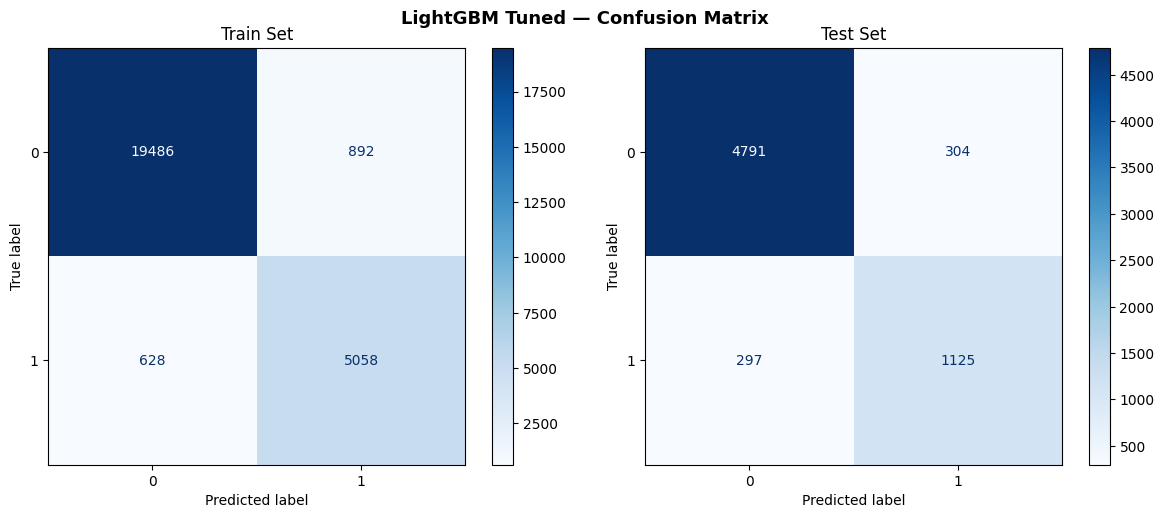

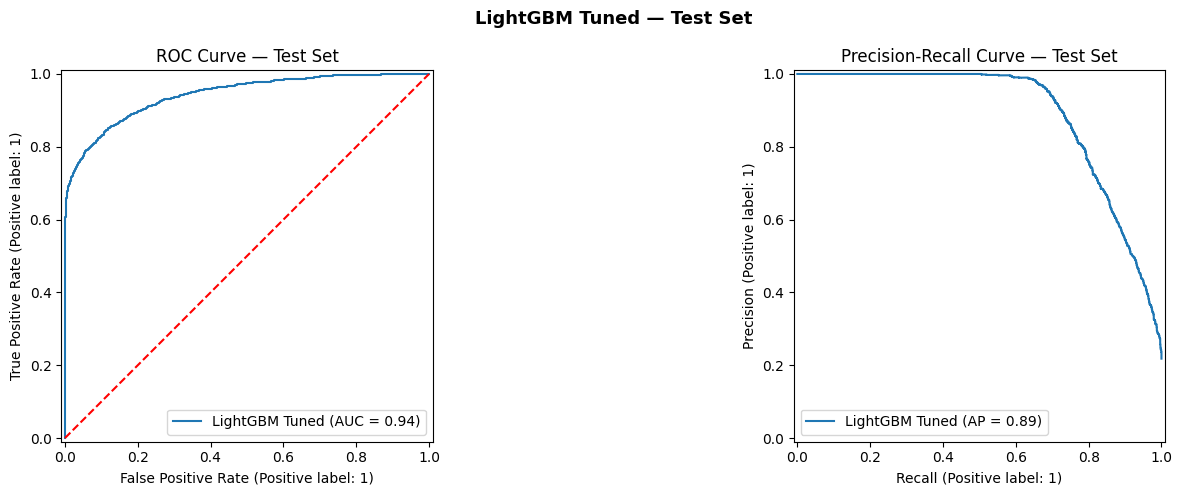

In [22]:
# set ngưỡng phân loại mặc định
threshold = 0.5

# Dự đoán xác suất rủi ro (lớp 1) bằng mô hình đã tối ưu lgbm_pipeline
y_train_proba_tuned = lgbm_pipeline.predict_proba(X_train_LGBM)[:, 1]
y_test_proba_tuned = lgbm_pipeline.predict_proba(X_test_LGBM)[:, 1]

# Chuyển đổi xác suất thành nhãn nhị phân (0 hoặc 1) dựa trên ngưỡng
y_train_pred_tuned = (y_train_proba_tuned >= threshold).astype(int)
y_test_pred_tuned = (y_test_proba_tuned >= threshold).astype(int)

# 1. Classification Report & Metrics
print("Classification Report — TRAIN SET (Tuned)")
print(classification_report(y_train, y_train_pred_tuned))
print(f"ROC-AUC: {roc_auc_score(y_train, y_train_proba_tuned):.4f}")
print(f"PR-AUC: {average_precision_score(y_train, y_train_proba_tuned):.4f}")

print("\nClassification Report — TEST SET (Tuned)")
print(classification_report(y_test, y_test_pred_tuned))
print(f"ROC-AUC: {roc_auc_score(y_test, y_test_proba_tuned):.4f}")
print(f"PR-AUC: {average_precision_score(y_test, y_test_proba_tuned):.4f}")

# 2. Confusion Matrix
matrix_train = confusion_matrix(y_train, y_train_pred_tuned, labels=[0, 1])
matrix_test = confusion_matrix(y_test,  y_test_pred_tuned,  labels=[0, 1])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("LightGBM Tuned — Confusion Matrix", fontsize=13, fontweight="bold")

ConfusionMatrixDisplay(matrix_train, display_labels=["0", "1"]).plot(
    ax=axes[0], values_format="d", colorbar=True, cmap="Blues")
axes[0].set_title("Train Set")

ConfusionMatrixDisplay(matrix_test, display_labels=["0", "1"]).plot(
    ax=axes[1], values_format="d", colorbar=True, cmap="Blues")
axes[1].set_title("Test Set")

plt.tight_layout()
plt.show()

# 3. ROC & PR Curves
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("LightGBM Tuned — Test Set", fontsize=13, fontweight="bold")

# Vẽ ROC Curve
RocCurveDisplay.from_predictions(
    y_test, y_test_proba_tuned, name="LightGBM Tuned", ax=axes[0])
axes[0].plot([0, 1], [0, 1], color="red", linestyle="--")
axes[0].set_title("ROC Curve — Test Set")
axes[0].legend()

# Vẽ Precision-Recall Curve
PrecisionRecallDisplay.from_predictions(
    y_test, y_test_proba_tuned, name="LightGBM Tuned", ax=axes[1])
axes[1].set_title("Precision-Recall Curve — Test Set")

plt.tight_layout()
plt.show()
